# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image
import os

In [2]:
import ctypes
import os

lib_path = os.path.join(os.getcwd(), "ml_lib/target/debug/libml_lib.dylib")
ml_lib = ctypes.cdll.LoadLibrary(lib_path)

In [3]:
# Je dis a Python comment parler a chaque fonction Rust
# argtypes = ce qu on envoie a la fonction
# restype  = ce qu elle nous renvoie
# Sans ca Python envoie les mauvais types et ca plante

# Modele Lineaire
ml_lib.create_linear_model.argtypes = [ctypes.c_size_t, ctypes.c_float]
ml_lib.create_linear_model.restype  = ctypes.c_void_p
ml_lib.train_step.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.c_float]
ml_lib.train_step.restype  = None
ml_lib.predict.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t]
ml_lib.predict.restype  = ctypes.c_float
ml_lib.free_linear_model.argtypes = [ctypes.c_void_p]
ml_lib.free_linear_model.restype  = None
ml_lib.save_linear_model.argtypes = [ctypes.c_void_p, ctypes.c_char_p]
ml_lib.save_linear_model.restype  = None
ml_lib.load_linear_model.argtypes = [ctypes.c_char_p]
ml_lib.load_linear_model.restype  = ctypes.c_void_p

# PMC
ml_lib.create_pmc.argtypes = [ctypes.c_size_t, ctypes.c_size_t, ctypes.c_size_t, ctypes.c_float]
ml_lib.create_pmc.restype = ctypes.c_void_p
ml_lib.pmc_train_step.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t]
ml_lib.pmc_train_step.restype = None
ml_lib.pmc_predict.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.POINTER(ctypes.c_float)]
ml_lib.pmc_predict.restype = None
ml_lib.free_pmc.argtypes = [ctypes.c_void_p]
ml_lib.free_pmc.restype = None
ml_lib.save_pmc.argtypes = [ctypes.c_void_p, ctypes.c_char_p]
ml_lib.save_pmc.restype  = None
ml_lib.load_pmc.argtypes = [ctypes.c_char_p]
ml_lib.load_pmc.restype  = ctypes.c_void_p

# RBFN
ml_lib.create_rbfn.argtypes = [ctypes.c_size_t, ctypes.c_size_t, ctypes.c_size_t, ctypes.c_float, ctypes.c_float]
ml_lib.create_rbfn.restype = ctypes.c_void_p
ml_lib.rbfn_set_centers.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t]
ml_lib.rbfn_set_centers.restype = None
ml_lib.rbfn_train_step.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t]
ml_lib.rbfn_train_step.restype = None
ml_lib.rbfn_predict.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_float), ctypes.c_size_t, ctypes.POINTER(ctypes.c_float)]
ml_lib.rbfn_predict.restype = None
ml_lib.free_rbfn.argtypes = [ctypes.c_void_p]
ml_lib.free_rbfn.restype = None
ml_lib.save_rbfn.argtypes = [ctypes.c_void_p, ctypes.c_char_p]
ml_lib.save_rbfn.restype  = None
ml_lib.load_rbfn.argtypes = [ctypes.c_char_p]
ml_lib.load_rbfn.restype  = ctypes.c_void_p

# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [4]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

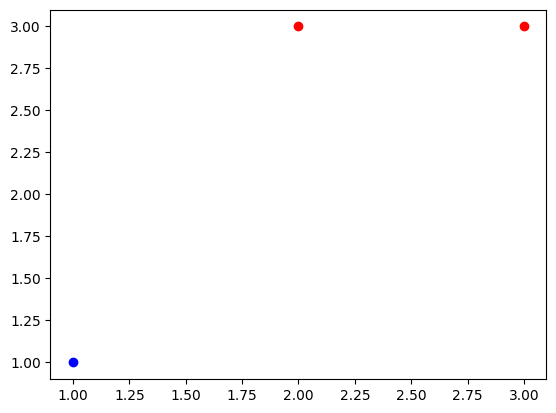

<Figure size 640x480 with 0 Axes>

In [5]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

In [6]:
N = 2
lr = 0.01
epochs = 1000

model = ml_lib.create_linear_model(N, ctypes.c_float(lr))

for epoch in range(epochs):
    for i in range(len(X)):
        x = np.array(X[i], dtype=np.float32)
        x_ptr = np.ctypeslib.as_ctypes(x)
        ml_lib.train_step(model, x_ptr, N, ctypes.c_float(float(Y[i])))

print("Entrainement termine")

Entrainement termine


In [7]:
for i in range(len(X)):
    x = np.array(X[i], dtype=np.float32)
    x_ptr = np.ctypeslib.as_ctypes(x)
    prediction = ml_lib.predict(model, x_ptr, N)
    classe = "bleu" if prediction >= 0 else "rouge"
    vraie_classe = "bleu" if Y[i] == 1 else "rouge"
    correct = "OK" if classe == vraie_classe else "KO"
    print(classe, vraie_classe, correct)

ml_lib.free_linear_model(model)

bleu bleu OK
rouge rouge OK
rouge rouge OK


In [8]:
N = 2
pmc_ls = ml_lib.create_pmc(N, 4, 1, ctypes.c_float(0.1))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_ls, point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_ls, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0.5 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("PMC Linear Simple", correct, "/", len(X))
ml_lib.free_pmc(pmc_ls)

PMC Linear Simple 3 / 3


In [9]:
N = 2
nb_centres = 3
rbfn_ls = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(2.0), ctypes.c_float(0.1))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_ls, centres_pour_rust, len(centres))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_ls, point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_ls, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("RBFN Linear Simple", correct, "/", len(X))
ml_lib.free_rbfn(rbfn_ls)

RBFN Linear Simple 3 / 3


In [10]:
N = 2
model_save = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(1000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_save, point_pour_rust, N, ctypes.c_float(float(Y[i])))

ml_lib.save_linear_model(model_save, b"model_lineaire.bin")
print("modele sauvegarde")
ml_lib.free_linear_model(model_save)

model_charge = ml_lib.load_linear_model(b"model_lineaire.bin")
print("modele charge")

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_charge, point_pour_rust, N)
    classe = "bleu" if prediction >= 0 else "rouge"
    print(classe)

ml_lib.free_linear_model(model_charge)

modele sauvegarde
modele charge
bleu
rouge
rouge


### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [11]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

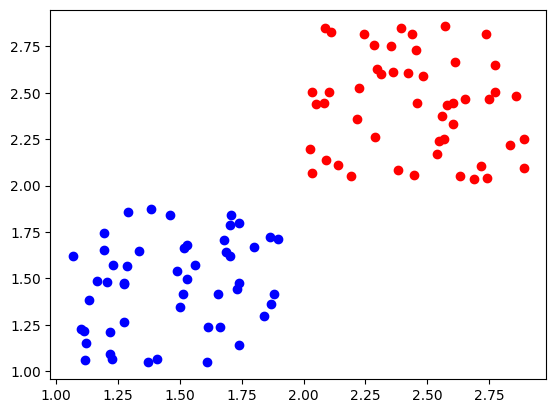

<Figure size 640x480 with 0 Axes>

In [12]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

In [13]:
N = 2
model_lm = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(1000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_lm, point_pour_rust, N, ctypes.c_float(float(Y[i].item())))

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_lm, point_pour_rust, N)
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score Lineaire Multiple", correct, "/", len(X))
ml_lib.free_linear_model(model_lm)

Score Lineaire Multiple 100 / 100


In [14]:
N = 2
pmc_lm = ml_lib.create_pmc(N, 4, 1, ctypes.c_float(0.1))

for epoch in range(5000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i].item())], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_lm, point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_lm, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0.5 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score PMC Linear Multiple", correct, "/", len(X))
ml_lib.free_pmc(pmc_lm)

Score PMC Linear Multiple 100 / 100


In [15]:
N = 2
nb_centres = 10
rbfn_lm = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_lm, centres_pour_rust, len(centres))

for epoch in range(5000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i].item())], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_lm, point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_lm, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score RBFN Linear Multiple", correct, "/", len(X))
ml_lib.free_rbfn(rbfn_lm)

Score RBFN Linear Multiple 96 / 100


### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [16]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

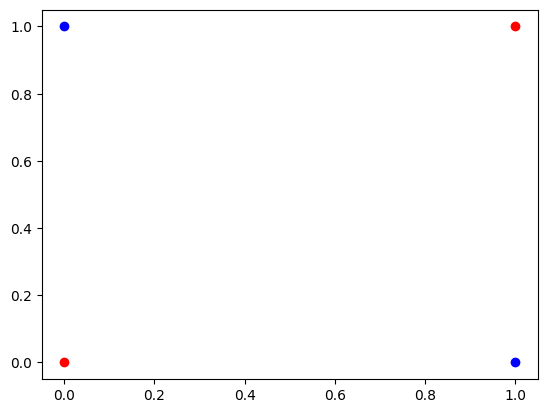

<Figure size 640x480 with 0 Axes>

In [17]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

In [18]:
N = 2
model_xor = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(1000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_xor, point_pour_rust, N, ctypes.c_float(float(Y[i])))

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_xor, point_pour_rust, N)
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score Lineaire XOR", correct, "/", len(X))
ml_lib.free_linear_model(model_xor)

Score Lineaire XOR 2 / 4


In [19]:
N = 2
pmc_xor = ml_lib.create_pmc(N, 4, 1, ctypes.c_float(0.1))

for epoch in range(100000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_xor, point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_xor, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0.5 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score PMC XOR", correct, "/", len(X))
ml_lib.free_pmc(pmc_xor)

Score PMC XOR 4 / 4


In [20]:
N = 2
nb_centres = 4
rbfn_xor = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(2.0), ctypes.c_float(0.1))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_xor, centres_pour_rust, len(centres))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_xor, point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_xor, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score RBFN XOR", correct, "/", len(X))
ml_lib.free_rbfn(rbfn_xor)

Score RBFN XOR 4 / 4


In [21]:
N = 2
pmc_save = ml_lib.create_pmc(N, 4, 1, ctypes.c_float(0.1))

for epoch in range(100000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_save, point_pour_rust, N, label_pour_rust, 1)

ml_lib.save_pmc(pmc_save, b"pmc_xor.bin")
print("pmc sauvegarde")
ml_lib.free_pmc(pmc_save)

pmc_charge = ml_lib.load_pmc(b"pmc_xor.bin")
print("pmc charge")

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_charge, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0.5 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score apres chargement", correct, "/", len(X))
ml_lib.free_pmc(pmc_charge)

pmc sauvegarde
pmc charge
Score apres chargement 4 / 4


In [22]:
N = 2
nb_centres = 4
rbfn_save = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(2.0), ctypes.c_float(0.1))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_save, centres_pour_rust, len(centres))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_save, point_pour_rust, N, label_pour_rust, 1)

ml_lib.save_rbfn(rbfn_save, b"rbfn_xor.bin")
print("rbfn sauvegarde")
ml_lib.free_rbfn(rbfn_save)

rbfn_charge = ml_lib.load_rbfn(b"rbfn_xor.bin")
print("rbfn charge")

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_charge, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score apres chargement", correct, "/", len(X))
ml_lib.free_rbfn(rbfn_charge)

rbfn sauvegarde
rbfn charge
Score apres chargement 4 / 4


























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [23]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

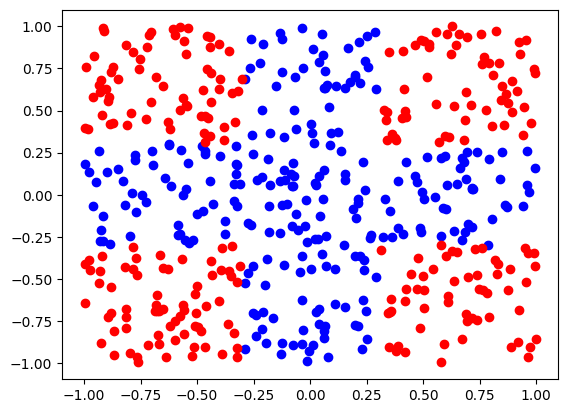

<Figure size 640x480 with 0 Axes>

In [24]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

In [25]:
N = 2
model_cross = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(1000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_cross, point_pour_rust, N, ctypes.c_float(float(Y[i])))

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_cross, point_pour_rust, N)
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score Lineaire Cross", correct, "/", len(X))
ml_lib.free_linear_model(model_cross)

Score Lineaire Cross 272 / 500


In [26]:
N = 2
pmc_cross = ml_lib.create_pmc(N, 4, 1, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_cross, point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_cross, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0.5 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score PMC Cross", correct, "/", len(X))
ml_lib.free_pmc(pmc_cross)

Score PMC Cross 391 / 500


In [27]:
N = 2
nb_centres = 20
rbfn_cross = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(2.0), ctypes.c_float(0.01))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_cross, centres_pour_rust, len(centres))

for epoch in range(5000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_cross, point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_cross, point_pour_rust, N, resultat_pour_rust)
    prediction = 1 if resultat[0] >= 0 else -1
    if (prediction >= 0 and Y[i] == 1) or (prediction < 0 and Y[i] == -1):
        correct += 1

print("Score RBFN Cross", correct, "/", len(X))
ml_lib.free_rbfn(rbfn_cross)

Score RBFN Cross 397 / 500


### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [28]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

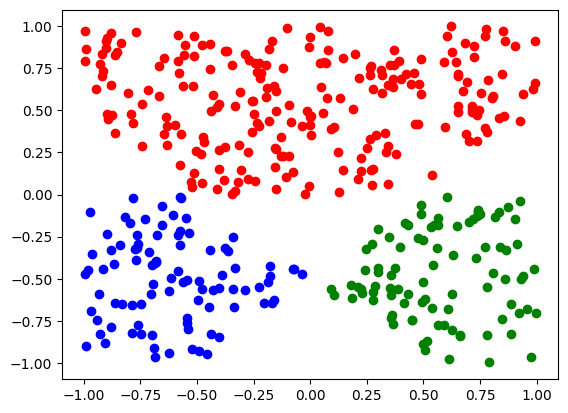

<Figure size 640x480 with 0 Axes>

In [29]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

In [30]:
N = 2
nb_classes = 3
modeles = []

for k in range(nb_classes):
    m = ml_lib.create_linear_model(N, ctypes.c_float(0.01))
    modeles.append(m)

for epoch in range(1000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        for k in range(nb_classes):
            ml_lib.train_step(modeles[k], point_pour_rust, N, ctypes.c_float(float(Y[i][k])))

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    scores = [ml_lib.predict(modeles[k], point_pour_rust, N) for k in range(nb_classes)]
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print("Score Lineaire Multi Linear", correct, "/", len(X))

for m in modeles:
    ml_lib.free_linear_model(m)

Score Lineaire Multi Linear 407 / 407


In [31]:
N = 2
nb_classes = 3
pmc_modeles = []

for k in range(nb_classes):
    m = ml_lib.create_pmc(N, 8, 1, ctypes.c_float(0.01))
    pmc_modeles.append(m)

for epoch in range(5000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        for k in range(nb_classes):
            label = np.array([float(Y[i][k])], dtype=np.float32)
            label_pour_rust = np.ctypeslib.as_ctypes(label)
            ml_lib.pmc_train_step(pmc_modeles[k], point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    scores = []
    for k in range(nb_classes):
        resultat = np.zeros(1, dtype=np.float32)
        resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
        ml_lib.pmc_predict(pmc_modeles[k], point_pour_rust, N, resultat_pour_rust)
        scores.append(resultat[0])
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print("Score PMC Multi Linear", correct, "/", len(X))

for m in pmc_modeles:
    ml_lib.free_pmc(m)

Score PMC Multi Linear 407 / 407


In [32]:
N = 2
nb_classes = 3
nb_centres = 15
rbfn_modeles = []

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)

for k in range(nb_classes):
    m = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))
    ml_lib.rbfn_set_centers(m, centres_pour_rust, len(centres))
    rbfn_modeles.append(m)

for epoch in range(2000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        for k in range(nb_classes):
            label = np.array([float(Y[i][k])], dtype=np.float32)
            label_pour_rust = np.ctypeslib.as_ctypes(label)
            ml_lib.rbfn_train_step(rbfn_modeles[k], point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    scores = []
    for k in range(nb_classes):
        resultat = np.zeros(1, dtype=np.float32)
        resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
        ml_lib.rbfn_predict(rbfn_modeles[k], point_pour_rust, N, resultat_pour_rust)
        scores.append(resultat[0])
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print("Score RBFN Multi Linear", correct, "/", len(X))

for m in rbfn_modeles:
    ml_lib.free_rbfn(m)

Score RBFN Multi Linear 407 / 407


### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [33]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

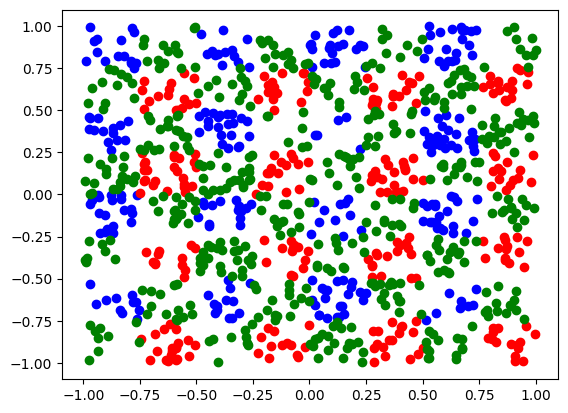

<Figure size 640x480 with 0 Axes>

In [34]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

In [35]:
N = 2
nb_classes = 3
modeles_cross = []

for k in range(nb_classes):
    m = ml_lib.create_linear_model(N, ctypes.c_float(0.01))
    modeles_cross.append(m)

for epoch in range(1000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        for k in range(nb_classes):
            ml_lib.train_step(modeles_cross[k], point_pour_rust, N, ctypes.c_float(float(Y[i][k])))

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    scores = [ml_lib.predict(modeles_cross[k], point_pour_rust, N) for k in range(nb_classes)]
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print("Score Lineaire Multi Cross", correct, "/", len(X))

for m in modeles_cross:
    ml_lib.free_linear_model(m)

Score Lineaire Multi Cross 477 / 1000


In [36]:
N = 2
nb_classes = 3
pmc_multi = ml_lib.create_pmc(N, 16, nb_classes, ctypes.c_float(0.1))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array(Y[i], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_multi, point_pour_rust, N, label_pour_rust, nb_classes)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(nb_classes, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_multi, point_pour_rust, N, resultat_pour_rust)
    classe_predite = int(np.argmax(resultat))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print("Score PMC Multi Cross", correct, "/", len(X))
ml_lib.free_pmc(pmc_multi)

Score PMC Multi Cross 583 / 1000


In [37]:
N = 2
nb_classes = 3
nb_centres = 30
rbfn_multi = []

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)

for k in range(nb_classes):
    m = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(2.0), ctypes.c_float(0.01))
    ml_lib.rbfn_set_centers(m, centres_pour_rust, len(centres))
    rbfn_multi.append(m)

for epoch in range(5000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        for k in range(nb_classes):
            label = np.array([float(Y[i][k])], dtype=np.float32)
            label_pour_rust = np.ctypeslib.as_ctypes(label)
            ml_lib.rbfn_train_step(rbfn_multi[k], point_pour_rust, N, label_pour_rust, 1)

correct = 0
for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    scores = []
    for k in range(nb_classes):
        resultat = np.zeros(1, dtype=np.float32)
        resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
        ml_lib.rbfn_predict(rbfn_multi[k], point_pour_rust, N, resultat_pour_rust)
        scores.append(resultat[0])
    classe_predite = scores.index(max(scores))
    classe_reelle = list(Y[i]).index(1)
    if classe_predite == classe_reelle:
        correct += 1

print("Score RBFN Multi Cross", correct, "/", len(X))

for m in rbfn_multi:
    ml_lib.free_rbfn(m)

Score RBFN Multi Cross 479 / 1000


## Régression

### Linear Simple 2D :
        Linear Model : OK
        MLP (1, 1)   : OK

In [38]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

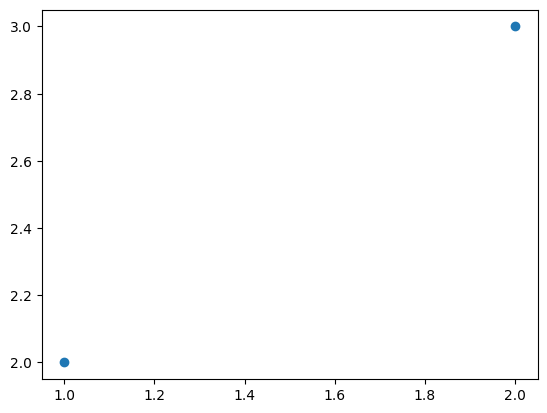

<Figure size 640x480 with 0 Axes>

In [39]:
plt.scatter(X,Y)
plt.show()
plt.clf()

In [40]:
N = 1
model_reg = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_reg, point_pour_rust, N, ctypes.c_float(float(Y[i])))

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_reg, point_pour_rust, N)
    print("X =", X[i][0], "predit =", round(float(prediction), 3), "vrai =", Y[i])

point_test = np.array([1.5], dtype=np.float32)
point_test_pour_rust = np.ctypeslib.as_ctypes(point_test)
prediction_test = ml_lib.predict(model_reg, point_test_pour_rust, N)
print("X = 1.5 predit =", round(float(prediction_test), 3), "vrai attendu = 2.5")

ml_lib.free_linear_model(model_reg)

X = 1 predit = 2.0 vrai = 2
X = 2 predit = 3.0 vrai = 3
X = 1.5 predit = 2.5 vrai attendu = 2.5


In [41]:
N = 1
pmc_reg = ml_lib.create_pmc(N, 7, 1, ctypes.c_float(0.01))

for epoch in range(100000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_reg, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_reg, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i][0], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_pmc(pmc_reg)

X = 1 predit = 2.0 vrai = 2
X = 2 predit = 3.0 vrai = 3


In [42]:
N = 1
nb_centres = 2
rbfn_reg = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_reg, centres_pour_rust, len(centres))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_reg, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_reg, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i][0], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_rbfn(rbfn_reg)

X = 1 predit = 2.0 vrai = 2
X = 2 predit = 3.0 vrai = 3


### Non Linear Simple 2D :
        Linear Model    : OK
        MLP (1, ?, 1)   : OK

In [43]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

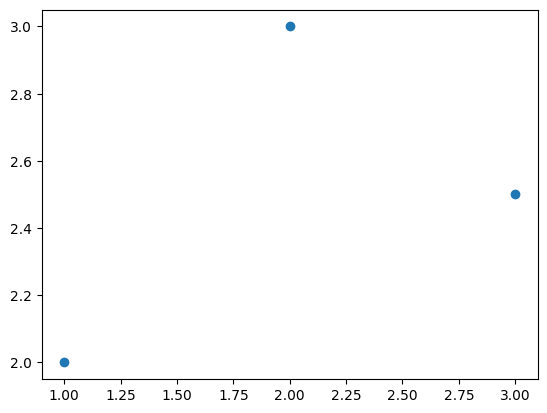

<Figure size 640x480 with 0 Axes>

In [44]:
plt.scatter(X,Y)
plt.show()
plt.clf()

In [45]:
N = 1
model_reg2 = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_reg2, point_pour_rust, N, ctypes.c_float(float(Y[i])))

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_reg2, point_pour_rust, N)
    print("X =", X[i][0], "predit =", round(float(prediction), 3), "vrai =", Y[i])

ml_lib.free_linear_model(model_reg2)

X = 1 predit = 2.257 vrai = 2.0
X = 2 predit = 2.494 vrai = 3.0
X = 3 predit = 2.731 vrai = 2.5


In [46]:
N = 1
pmc_reg2 = ml_lib.create_pmc(N, 7, 1, ctypes.c_float(0.01))

for epoch in range(100000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_reg2, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_reg2, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i][0], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_pmc(pmc_reg2)

X = 1 predit = 2.0 vrai = 2.0
X = 2 predit = 3.0 vrai = 3.0
X = 3 predit = 2.5 vrai = 2.5


In [47]:
N = 1
nb_centres = 3
rbfn_reg2 = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_reg2, centres_pour_rust, len(centres))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_reg2, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_reg2, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i][0], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_rbfn(rbfn_reg2)

X = 1 predit = 2.0 vrai = 2.0
X = 2 predit = 3.0 vrai = 3.0
X = 3 predit = 2.5 vrai = 2.5


### Linear Simple 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [48]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

In [49]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [50]:
N = 2
model_3d = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_3d, point_pour_rust, N, ctypes.c_float(float(Y[i])))

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_3d, point_pour_rust, N)
    print("X =", X[i], "predit =", round(float(prediction), 3), "vrai =", Y[i])

ml_lib.free_linear_model(model_3d)

X = [1 1] predit = 2.0 vrai = 2.0
X = [2 2] predit = 3.0 vrai = 3.0
X = [3 1] predit = 2.5 vrai = 2.5


In [51]:
N = 2
pmc_3d = ml_lib.create_pmc(N, 7, 1, ctypes.c_float(0.01))

for epoch in range(100000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_3d, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_3d, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_pmc(pmc_3d)

X = [1 1] predit = 2.0 vrai = 2.0
X = [2 2] predit = 3.0 vrai = 3.0
X = [3 1] predit = 2.5 vrai = 2.5


In [52]:
N = 2
nb_centres = 3
rbfn_3d = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_3d, centres_pour_rust, len(centres))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_3d, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_3d, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_rbfn(rbfn_3d)

X = [1 1] predit = 2.0 vrai = 2.0
X = [2 2] predit = 3.0 vrai = 3.0
X = [3 1] predit = 2.5 vrai = 2.5


### Linear Tricky 3D :
        Linear Model    : OK
        MLP (2, 1)      : OK

In [53]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

In [54]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [55]:
N = 2
model_tricky = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_tricky, point_pour_rust, N, ctypes.c_float(float(Y[i])))

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_tricky, point_pour_rust, N)
    print("X =", X[i], "predit =", round(float(prediction), 3), "vrai =", Y[i])

ml_lib.free_linear_model(model_tricky)

X = [1 1] predit = 1.0 vrai = 1
X = [2 2] predit = 2.0 vrai = 2
X = [3 3] predit = 3.0 vrai = 3


In [56]:
N = 2
pmc_tricky = ml_lib.create_pmc(N, 7, 1, ctypes.c_float(0.01))

for epoch in range(100000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_tricky, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_tricky, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_pmc(pmc_tricky)

X = [1 1] predit = 0.998 vrai = 1
X = [2 2] predit = 2.004 vrai = 2
X = [3 3] predit = 2.998 vrai = 3


In [57]:
N = 2
nb_centres = 3
rbfn_tricky = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_tricky, centres_pour_rust, len(centres))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_tricky, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_tricky, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_rbfn(rbfn_tricky)

X = [1 1] predit = 1.0 vrai = 1
X = [2 2] predit = 2.0 vrai = 2
X = [3 3] predit = 3.0 vrai = 3


### Non Linear Simple 3D :
        Linear Model       : KO
        MLP (2, 2, 1)      : OK

In [58]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

In [59]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [60]:
N = 2
model_nl3d = ml_lib.create_linear_model(N, ctypes.c_float(0.01))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        ml_lib.train_step(model_nl3d, point_pour_rust, N, ctypes.c_float(float(Y[i])))

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    prediction = ml_lib.predict(model_nl3d, point_pour_rust, N)
    print("X =", X[i], "predit =", round(float(prediction), 3), "vrai =", Y[i])

ml_lib.free_linear_model(model_nl3d)

X = [1 0] predit = 0.485 vrai = 2
X = [0 1] predit = -0.53 vrai = 1
X = [1 1] predit = -0.545 vrai = -2
X = [0 0] predit = 0.5 vrai = -1


In [61]:
N = 2
pmc_nl3d = ml_lib.create_pmc(N, 2, 1, ctypes.c_float(0.01))

for epoch in range(100000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.pmc_train_step(pmc_nl3d, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.pmc_predict(pmc_nl3d, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_pmc(pmc_nl3d)

X = [1 0] predit = 2.0 vrai = 2
X = [0 1] predit = 1.0 vrai = 1
X = [1 1] predit = -2.0 vrai = -2
X = [0 0] predit = -1.0 vrai = -1


In [62]:
N = 2
nb_centres = 4
rbfn_nl3d = ml_lib.create_rbfn(N, nb_centres, 1, ctypes.c_float(2.0), ctypes.c_float(0.01))

centres = np.array(X[:nb_centres], dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres)
ml_lib.rbfn_set_centers(rbfn_nl3d, centres_pour_rust, len(centres))

for epoch in range(10000):
    for i in range(len(X)):
        point = np.array(X[i], dtype=np.float32)
        point_pour_rust = np.ctypeslib.as_ctypes(point)
        label = np.array([float(Y[i])], dtype=np.float32)
        label_pour_rust = np.ctypeslib.as_ctypes(label)
        ml_lib.rbfn_train_step(rbfn_nl3d, point_pour_rust, N, label_pour_rust, 1)

for i in range(len(X)):
    point = np.array(X[i], dtype=np.float32)
    point_pour_rust = np.ctypeslib.as_ctypes(point)
    resultat = np.zeros(1, dtype=np.float32)
    resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
    ml_lib.rbfn_predict(rbfn_nl3d, point_pour_rust, N, resultat_pour_rust)
    print("X =", X[i], "predit =", round(float(resultat[0]), 3), "vrai =", Y[i])

ml_lib.free_rbfn(rbfn_nl3d)

X = [1 0] predit = 2.0 vrai = 2
X = [0 1] predit = 1.0 vrai = 1
X = [1 1] predit = -2.0 vrai = -2
X = [0 0] predit = -1.0 vrai = -1


In [63]:
classes = ["avion", "voiture", "bateau"]
N_lin = 1024

for k in range(3):
    print("Entrainement lineaire", classes[k])
    model_k = ml_lib.create_linear_model(N_lin, ctypes.c_float(0.0001))

    for epoch in range(10):
        random.shuffle(train)
        for (pixels, label) in train:
            point_pour_rust = np.ctypeslib.as_ctypes(pixels)
            y_val = 1.0 if label == k else -1.0
            ml_lib.train_step(model_k, point_pour_rust, N_lin, ctypes.c_float(y_val))

    ml_lib.save_linear_model(model_k, f"lineaire_{classes[k]}.bin".encode())
    ml_lib.free_linear_model(model_k)
    print("Lineaire", classes[k], "sauvegarde")

correct = 0
for (pixels, label) in test:
    point_pour_rust = np.ctypeslib.as_ctypes(pixels)
    scores = []
    for k in range(3):
        model_k = ml_lib.load_linear_model(f"lineaire_{classes[k]}.bin".encode())
        score = ml_lib.predict(model_k, point_pour_rust, N_lin)
        ml_lib.free_linear_model(model_k)
        scores.append(float(score))
    pred = scores.index(max(scores))
    if pred == label:
        correct += 1

print("Score lineaire sur test 20%", correct, "/", len(test), "=", round(correct/len(test)*100, 1), "%")

Entrainement lineaire avion


NameError: name 'train' is not defined

In [ ]:
def charger_images_gris(dossier, label, taille=(32, 32)):
    data = []
    for fichier in os.listdir(dossier):
        if fichier.endswith((".jpg", ".jpeg", ".png")):
            chemin = os.path.join(dossier, fichier)
            try:
                img = Image.open(chemin).convert("L").resize(taille)
                pixels = np.array(img, dtype=np.float32).flatten() / 255.0
                data.append((pixels, label))
            except:
                pass
    return data

data_dir = "ml_lib/data"
avions   = charger_images_gris(os.path.join(data_dir, "avions"),   0)
voitures = charger_images_gris(os.path.join(data_dir, "voitures"), 1)
bateaux  = charger_images_gris(os.path.join(data_dir, "bateau"),   2)

random.shuffle(avions)
random.shuffle(voitures)
random.shuffle(bateaux)

split_avions   = int(len(avions) * 0.8)
split_voitures = int(len(voitures) * 0.8)
split_bateaux  = int(len(bateaux) * 0.8)

train = avions[:split_avions] + voitures[:split_voitures] + bateaux[:split_bateaux]
test  = avions[split_avions:] + voitures[split_voitures:] + bateaux[split_bateaux:]
toutes_images = avions + voitures + bateaux

print("Avions", len(avions), "Voitures", len(voitures), "Bateaux", len(bateaux))
print("Train", len(train), "Test", len(test))

N_gris = 1024
classes = ["avion", "voiture", "bateau"]

for k in range(3):
    print("Entrainement PMC", classes[k])
    pmc_k = ml_lib.create_pmc(N_gris, 128, 1, ctypes.c_float(0.0001))

    for epoch in range(20):
        random.shuffle(train)
        for (pixels, label) in train:
            point_pour_rust = np.ctypeslib.as_ctypes(pixels)
            y_val = 1.0 if label == k else 0.0
            label_rust = np.ctypeslib.as_ctypes(np.array([y_val], dtype=np.float32))
            ml_lib.pmc_train_step(pmc_k, point_pour_rust, N_gris, label_rust, 1)

    ml_lib.save_pmc(pmc_k, f"pmc_{classes[k]}.bin".encode())
    ml_lib.free_pmc(pmc_k)
    print("PMC", classes[k], "sauvegarde")

correct = 0
for (pixels, label) in test:
    point_pour_rust = np.ctypeslib.as_ctypes(pixels)
    scores = []
    for k in range(3):
        pmc_k = ml_lib.load_pmc(f"pmc_{classes[k]}.bin".encode())
        resultat = np.zeros(1, dtype=np.float32)
        resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
        ml_lib.pmc_predict(pmc_k, point_pour_rust, N_gris, resultat_pour_rust)
        ml_lib.free_pmc(pmc_k)
        scores.append(resultat[0])
    pred = scores.index(max(scores))
    if pred == label:
        correct += 1

print("Score PMC sur test 20%", correct, "/", len(test), "=", round(correct/len(test)*100, 1), "%")

In [ ]:
classes = ["avion", "voiture", "bateau"]

centres_avion   = [p[0] for p in avions[:20]]
centres_voiture = [p[0] for p in voitures[:20]]
centres_bateau  = [p[0] for p in bateaux[:60]]
centres_tous    = centres_avion + centres_voiture + centres_bateau
centres_array   = np.array(centres_tous, dtype=np.float32).flatten()
centres_pour_rust = np.ctypeslib.as_ctypes(centres_array)

for k in range(3):
    print("Entrainement RBFN", classes[k])
    rbfn_k = ml_lib.create_rbfn(N_gris, 100, 1, ctypes.c_float(1.0), ctypes.c_float(0.01))
    ml_lib.rbfn_set_centers(rbfn_k, centres_pour_rust, len(centres_array))

    for epoch in range(10):
        random.shuffle(train)
        for (pixels, label) in train:
            point_pour_rust = np.ctypeslib.as_ctypes(pixels)
            y_val = 1.0 if label == k else 0.0
            label_rust = np.ctypeslib.as_ctypes(np.array([y_val], dtype=np.float32))
            ml_lib.rbfn_train_step(rbfn_k, point_pour_rust, N_gris, label_rust, 1)

    ml_lib.save_rbfn(rbfn_k, f"rbfn_{classes[k]}.bin".encode())
    ml_lib.free_rbfn(rbfn_k)
    print("RBFN", classes[k], "sauvegarde")

correct = 0
for (pixels, label) in test:
    point_pour_rust = np.ctypeslib.as_ctypes(pixels)
    scores = []
    for k in range(3):
        rbfn_k = ml_lib.load_rbfn(f"rbfn_{classes[k]}.bin".encode())
        resultat = np.zeros(1, dtype=np.float32)
        resultat_pour_rust = np.ctypeslib.as_ctypes(resultat)
        ml_lib.rbfn_predict(rbfn_k, point_pour_rust, N_gris, resultat_pour_rust)
        ml_lib.free_rbfn(rbfn_k)
        scores.append(resultat[0])
    pred = scores.index(max(scores))
    if pred == label:
        correct += 1

print("Score RBFN sur test 20%", correct, "/", len(test), "=", round(correct/len(test)*100, 1), "%")